# Saliency and Class Activation Map Visualization using PyTorch & ResNet

Deep learning models are often described as "black boxes". You input an image and get a prediction, but how does the model decide what it sees? The decision making process often remains opaque.

There's a whole family of techniques called interpretability and these are methods which reveal which part of the input most affected a model's prediction.

In high-stakes settings like medical imaging or self-driving cars, people want to see what guided the decision before they rely on that decision. Second, debugging. You can catch when a model makes the right call for the wrong reason. You can reveal surprising patterns, the kind of details that no one had thought to look for until the model brought them into focus. And finally, ethical concerns. These techniques can surface when a model behaves differently across different groups of people and it's important to know that before you put it in practice.

**Saliency maps** and **Grad-CAM (Gradient weighted Class Activation Mapping)** are two pivotal visualization techniques that help you "peek inside" the decision process of a model.
They allow you to identify which areas or pixels in an image matter most to the network for a particular prediction.

In this lab, you will:

* Load and preprocess images for a pre-trained ResNet model.
* Perform predictions and retrieve class probabilities.
* Compute **saliency maps** by backpropagating gradients from the target class all the way to the input pixels.
* Compute **class activation ("attention") maps** (Grad-CAM) to visualize the spatial regions that influenced the choice of the model.
* Overlay these visualizations on top of the original images to interpret the focus of the model.
* Understand the intuition and mathematics behind each visualization, with step by step explanations of the code.

Let's get started!

## Imports

In [1]:
import os

import cv2
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from skimage.transform import resize
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms

import helper_utils

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Loading the Pretrained ResNet50 and Class Labels

### Loading the Pretrained ResNet50 Model

You will utilize ResNet50, a powerful convolutional neural network trained on the [ImageNet](https://www.image-net.org/) dataset (1000 classes).

Saliency maps can be computed for any image classifier, but ImageNet models are excellent illustrations for this purpose.

You should also fetch the class label names for making your outputs human readable.

In [3]:
# Load pretrained ResNet50 model and class labels from local cache
torch.hub.set_dir(os.path.join(os.getcwd(), 'pretrained_model'))
model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1).eval()
model.to(device)

# Class names
imagenet_class_mapping = tv_models.ResNet50_Weights.IMAGENET1K_V1.meta["categories"]
print(f"Loaded {len(imagenet_class_mapping)} classes.")

Loaded 1000 classes.


### Image Preprocessing

ResNet50 requires the following input specifications:

* Images as RGB, shape `(224, 224)`
* Pixel normalization using ImageNet statistics:
  `mean = [0.485, 0.456, 0.406]`, `std = [0.229, 0.224, 0.225]`

The following code demonstrates how you process an image from a file into a tensor:

In [4]:
# Image preprocessing transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def load_image(img_path):
    img = Image.open(img_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

### Prediction and Visualizing Inputs

You will now load an image, transform it, and obtain the top prediction from the model.

You are encouraged to use your own images or try the examples provided below (place them in an `images/` folder):

Predicted class: Labrador retriever (prob: 0.458)



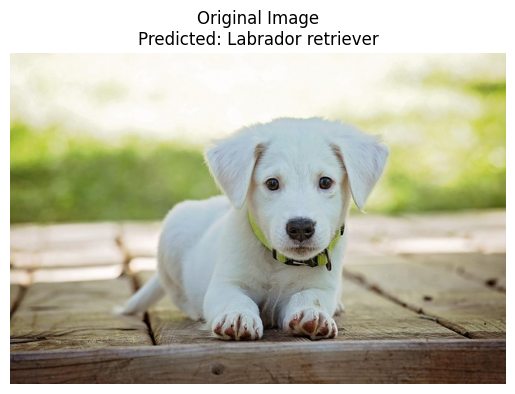

In [5]:
img_path = 'images/dog.jpg'  # Change to your own image path

if not os.path.exists(img_path):
    raise FileNotFoundError("Please provide a valid path to an image.")

img_pil = load_image(img_path)
img_tensor = transform(img_pil).unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1)
    pred_prob, pred_class = torch.max(probs, dim=1)
    pred_label = imagenet_class_mapping[pred_class]
print(f"Predicted class: {pred_label} (prob: {pred_prob.item():.3f})\n")

# Show the image
plt.imshow(np.array(img_pil))
plt.title(f"Original Image\nPredicted: {pred_label}")
plt.axis('off')
plt.show()

## Saliency Maps

### Understanding the Theory

When you employ a deep neural network to classify images, it is often helpful to "see what the model is looking at."
A **saliency map** helps you visualize which parts of an image are most important for the decision of your model.
* Think of it as a heatmap, where "hot" pixels strongly influence the prediction.

How does this function?
* Consider how your model would "feel" a change in each pixel: "If I change this pixel, does my prediction score rise or fall?"
* The **saliency map** answers this: it measures, for each input pixel, the extent to which changing that pixel would change the score for the target class.

<details>
<summary><strong>Show mathematical details</strong></summary>
<br>

For an input image $x$ and model output $f(x)$,  
if you are interested in class $c$, you compute:

$$S_{i, j} = \left| \frac{\partial f_c(x)}{\partial x_{i, j}} \right|$$

Where:
* $f_c(x)$: The score (before softmax) of the model for class $c$.
* $x_{i, j}$: Pixel value at position $(i, j)$ of the input image.

**In practice**:
* You compute the gradient of the output for class $c$ with respect to each pixel in the input image.
* You take the absolute value, and typically sum across color channels.
* This provides you with a single heatmap that reveals which pixels most affect the prediction for class $c$.

</details>

Any tensor in the computation graph can carry gradients, and not just the parameters. 

A number for each pixel that says how sensitive the prediction is to a small change in that value. So when you see a saliency map, you're looking at those input gradients lined up with the pixels of the image. Big gradients mean that the pixel has a strong local influence on the score.

But keep in mind, this shows sensitivity, not causation. A bright pixel does not prove that the model looked at features the way that a human would. It only means that the class score is especially sensitive to changes here.

To save memory, it only keeps gradients for tensors that actually matter for training, like your model's weights. If it tried to store gradients for every intermediate result in the forward pass, your memory would fill up almost instantly. That means if a tensor is the output of an operation created from other tensors, PyTorch will treat it as an intermediate. Intermediates still pass gradients backwards, but they don't keep their own gradients. .detach() breaks the history, and .clone() makes a fresh copy. Now that will give you a clean starting tensor, and PyTorch calls this a leaf. Once the tensor is reset as a leaf, you can tell PyTorch to track gradients for it with requires_grad, and then you'll run your forward pass.

A saliency map is just the gradient of the class score with respect to each input pixel. Large gradients mean the prediction is especially sensitive to that pixel. It's a pixel-level view of what drove the model's choice.

In [6]:
def compute_saliency_map(model, input_image, target_class=None):
    """
    Computes a saliency map for an input image using the gradients of the
    model's output with respect to the input pixels.

    Args:
        model: The neural network model used for classification.
        input_image: The input tensor image of shape [1, 3, H, W].
        target_class: The index of the target class for which the saliency
            map is computed. If None, the predicted class is used.

    Returns:
        saliency_map: A 2D numpy array representing pixel importance.
        pred_class: The index of the class used for the computation.
        pred_prob: The confidence score for the selected class.
    """
    # Clone the input and enable gradient tracking for the tensor
    input_image = input_image.clone().detach()
    input_image.requires_grad_()

    # Perform a forward pass to obtain the model logits
    output = model(input_image)

    # Calculate probabilities and determine the class for saliency analysis
    probs = torch.softmax(output, dim=1)
    if target_class is None:
        pred_prob, pred_class = torch.max(probs, dim=1)
        target_class = pred_class.item()
        pred_prob = pred_prob.item()
    else:
        pred_prob = probs[0, target_class].item()
        pred_class = target_class

    # Reset existing gradients in the model parameters
    model.zero_grad()

    # Execute backward pass to find gradients of the target class score
    output[0, target_class].backward()

    # Extract gradients of the output with respect to the input image
    gradients = input_image.grad.data[0]

    # Reduce the color channels by taking the absolute sum for a 2D map
    saliency_map = torch.abs(gradients).sum(dim=0).cpu().numpy()

    # Rescale the saliency map values to a range between 0 and 1
    saliency_map = (saliency_map - saliency_map.min()) / (
        saliency_map.max() - saliency_map.min() + 1e-8)

    return saliency_map, pred_class, pred_prob

In [7]:
saliency_map, pred_class, pred_prob = compute_saliency_map(model, img_tensor)
print("saliency_map shape:", saliency_map.shape)
print("pred_class:", pred_class)
print("pred_prob:", pred_prob)
print("Class label:", imagenet_class_mapping[pred_class])

saliency_map shape: (224, 224)
pred_class: tensor([208], device='cuda:0')
pred_prob: 0.45845291018486023
Class label: Labrador retriever


### Compute and Visualize the Saliency Map

You will now compute the map and overlay it on the original image.

In [8]:
def visualize_saliency(img_display, saliency_map, pred_class, pred_score, title):
    """
    Displays the original image, an enhanced saliency map, and an overlay.

    Args:
        img_display: Original image as a numpy array in uint8 format.
        saliency_map: Computed saliency array with values in range [0, 1].
        pred_class: Predicted class label or index for the image.
        pred_score: Numerical confidence score for the prediction.
        title: String identifier used for the plot title.

    Returns:
        None. Displays a three-panel matplotlib figure.
    """
    # Initialize a figure with three subplots for side-by-side visualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # Display the original input image in the first panel
    ax1.imshow(img_display)
    ax1.set_title(f'Original Image: {title}', fontsize=14)
    ax1.axis('off')

    # Apply gamma correction to enhance the contrast of the saliency map
    gamma = 0.7
    saliency_map_enhanced = np.power(saliency_map, gamma)

    # Determine dimensions and resize saliency map to match the source image
    h, w = img_display.shape[:2]
    saliency_map_resized = resize(
        saliency_map_enhanced, (h, w),
        order=1, mode='reflect', anti_aliasing=True
    )

    # Plot the enhanced saliency heatmap in the second panel
    saliency_heatmap = ax2.imshow(saliency_map_resized, cmap='inferno')
    ax2.set_title('Enhanced Saliency Map', fontsize=14)
    ax2.axis('off')
    fig.colorbar(saliency_heatmap, ax=ax2, fraction=0.046, pad=0.04)

    # Map the saliency values to the inferno colormap for RGB representation
    heatmap = cm.inferno(saliency_map_resized)[..., :3]
    # Normalize the display image and apply a fade factor for the background
    img_normalized = img_display / 255.0
    fade_factor = 0.3
    img_faded = img_normalized * fade_factor

    # Convert the faded image to grayscale to emphasize the saliency colors
    img_gray = np.mean(img_faded, axis=2, keepdims=True)
    img_gray = np.repeat(img_gray, 3, axis=2)

    # Define the alpha transparency and weight for the saliency overlay
    alpha = saliency_map_resized[:, :, np.newaxis]
    saliency_weight = 0.9

    # Blend the grayscale background with the colored heatmap
    overlay = (1 - alpha * saliency_weight) * img_gray + (
        alpha * saliency_weight) * heatmap
    # Clip values to ensure the final image stays within the valid [0, 1] range
    overlay = np.clip(overlay, 0, 1)

    # Render the combined overlay in the third panel with prediction details
    ax3.imshow(overlay)
    ax3.set_title(
        f'Saliency Overlay\nPrediction: {pred_class}\n'
        f'Confidence: {pred_score:.2f}', fontsize=14
    )
    ax3.axis('off')

    # Adjust layout to prevent overlapping and render the plots
    plt.tight_layout()
    plt.show()

Let's put it together:
* Load the image
* Obtain a prediction
* Generate the saliency map
* Visualize everything!

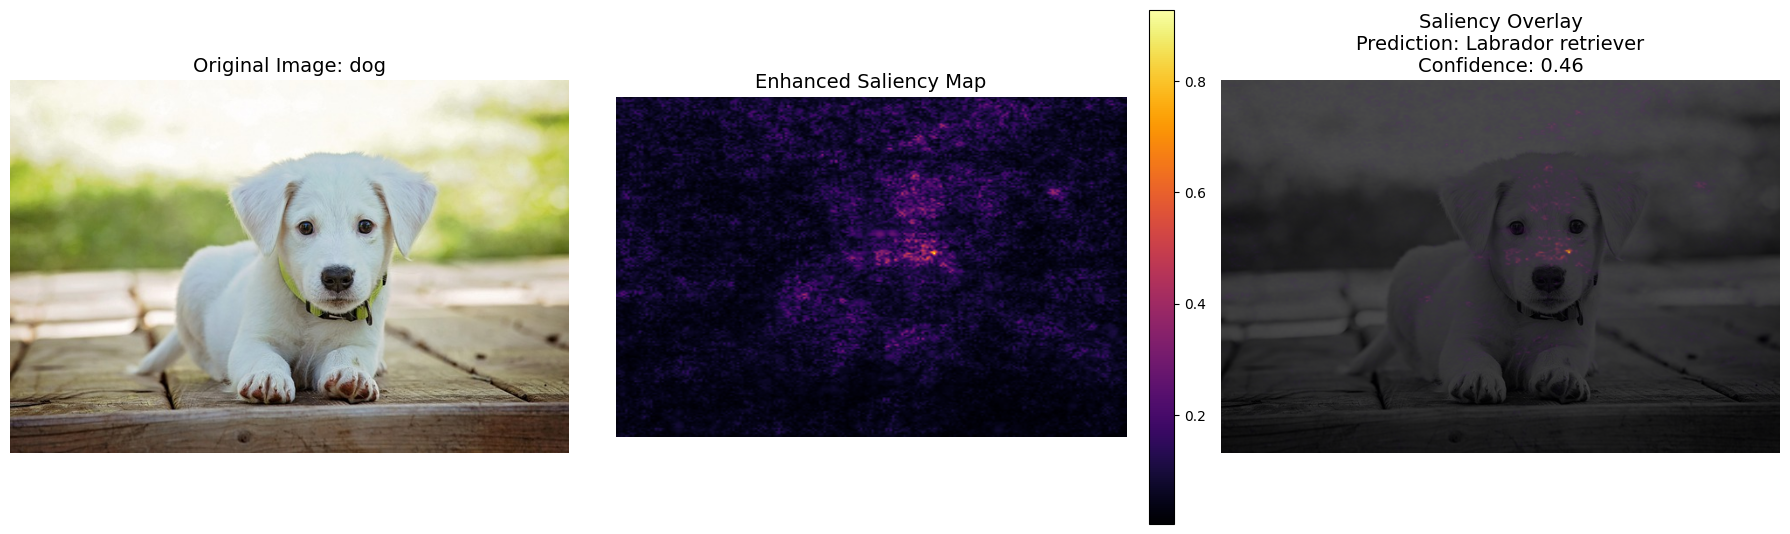

In [9]:
# Reload your original (untransformed) image for display
img_display = np.array(img_pil)

# Compute saliency map
sal_map, pred_class_index, pred_prob = compute_saliency_map(model, img_tensor)

# Show results!
visualize_saliency(
    img_display,
    sal_map,
    imagenet_class_mapping[pred_class_index],
    pred_prob,
    title=os.path.splitext(os.path.basename(img_path))[0]
)

## Grad-CAM: Visualizing Model Attention

### Understanding the Theory

Grad-CAM works by combining the **"attention" map** of your model (from its deepest convolutional layer) with the **gradient of the output for the target class**.
* In other words: You see *where* the model looked when deciding "this is a cat!" or "this is a dog!".

The algorithm operates as follows at a high level:
1. The image passes through the CNN; activations (feature maps) from the last convolutional layer are saved.
2. The gradient of the class score (for the class you care about) is computed with respect to these feature maps.
3. These gradients are averaged (global average pooling) to obtain "importance weights" for each channel.
4. The feature maps are weighted by their importance and summed.
5. The map passes through a ReLU function (so only positive influences remain).
6. The heatmap is upsampled and overlaid on the input image for interpretation.

<details>
<summary><strong>Details & Formula (click to expand)</strong></summary>
<br>
    
If $A^k$ is the $k$-th feature map in the last conv layer, and $y^c$ is the output for class $c$,

* Importance weight:
  $$\quad \alpha_k^c = \frac{1}{Z} \sum_i\sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$
* Grad-CAM:
 $$\quad L^{c}_{\text{Grad-CAM}} = \mathrm{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$

</details>

Rather than asking which pixels mattered, a more meaningful question could be which feature maps mattered most for this prediction, and in which regions did they light up? And that's the core idea behind class activation maps, or CAMs, the main focus of this module.

As you go deeper, each activation is influenced by a larger region of pixels, and it becomes sensitive to more complex patterns. That's why the last convolutional layer is usually best. It's where the maps capture the richest patterns over relatively large regions.

You have thousands of feature maps, but there's also a lot of classes, and that is a map tuned to ear shape might help for cats, but it doesn't help much for airplanes. So some maps are certainly more important than others for a given prediction. And now the question becomes, how do you figure out a way to rank the importance of each feature map with regards to the class of interest? It shouldn't be a surprise that you're going to want the gradients for each activation value in every single feature map, because they will tell you how changing any value in every seven by seven feature map will affect the class score.

The activation value at a location tells you how strongly that region lit up. The gradient in the gradient map at the same location tells you how much nudging that activation would change the class score. You could take the average of all the gradient values. This collapses the gradient maps into a single number, its weight. And that's what you want. On average, how strongly would changes to this feature map impact the overall class prediction? So do this for all 2048 feature maps, and you'll have 2048 weight values, one for each map. Every one of those 2048 feature maps has a weight that says how important it was for the class. So for each location in the seven-by-seven grid, you go across all 2048 maps, multiply that spot's activation by the map's weight, and add them all up. Do that for every position in the grid, and the result is a new seven-by-seven map where each number is the weighted sum of activations across all of the maps.

Then afterwards, you essentially apply a ReLU and only keep the positive values because those are the regions that helped the class prediction. Negative values would mean the opposite, so just throw them away. Now you've got your combined seven-by-seven map. The first thing you'll do is normalize the values so they all fall between zero and one. At this point, you can apply a color map to those numbers.

Resize that little grid so it stretches smoothly over the whole image. That resizing uses interpolation, basically filling in the gaps between the blocks so the color transitions look continuous instead of pixelated. And once that's done, you overlay it on the original image. Now you've turned your activations and gradients into a heat map.

In [10]:
class GradCAM:
    """
    A specific implementation of Gradient-weighted Class Activation Mapping (Grad-CAM).

    This class provides mechanisms to visualize which regions of an input image 
    are important for a specific classification decision by a Convolutional Neural Network.
    It attaches hooks to a target layer to capture feature maps and gradients, 
    then computes a coarse localization map based on the gradient flow.
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        """
        Initialize the GradCAM wrapper.

        This constructor stores the model and the specific layer to be analyzed,
        and registers a forward hook to intercept necessary data during inference.

        Args:
            model: The neural network instance to be interpreted.
            target_layer: The specific convolutional layer within the model to analyze.
        """
        self.model = model
        self.target_layer = target_layer
        # Initialize storage for activation maps
        self.activations = None   # [N,C,H',W']
        # Initialize storage for gradients
        self.gradients = None     # [N,C,H',W']
        # Register the forward hook on the target layer to capture data during the forward pass
        self.target_layer.register_forward_hook(self._on_forward)

    def _on_forward(self, module, inputs, output):
        """
        Internal callback to capture forward activations and register backward hooks.

        Args:
            module: The layer triggering the hook.
            inputs: The input tensors to the layer.
            output: The output tensors from the layer.
        """
        # Save the activations from the forward pass
        self.activations = output.detach()
        def _on_backward(grad):
            # Capture the gradients flowing back to this layer during backpropagation
            self.gradients = grad.detach()
        # Register a hook on the output tensor to capture gradients during the backward pass
        output.register_hook(_on_backward)

    def __call__(self, x: torch.Tensor, class_idx: int | None = None):
        """
        Execute the Grad-CAM generation pipeline.

        This method performs a forward pass, computes the gradients for a specific class,
        and generates the heatmap by weighting the forward activations with the computed gradients.

        Args:
            x: The input image tensor with shape [1, 3, H, W].
            class_idx: The specific class index to visualize. If None, uses the highest predicted class.

        Returns:
            A tuple containing the generated heatmap as a numpy array and the class index used.
        """
        # Clear existing gradients in the model to ensure a clean state
        self.model.zero_grad(set_to_none=True)
        # Perform the forward pass to get logits
        output = self.model(x)  # logits [1, num_classes]
        # Determine the target class index if not provided
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        # Isolate the score for the target class
        score = output[:, class_idx].sum()
        # Trigger backpropagation to compute gradients relative to the target class
        score.backward()

        # Compute the global average pooling of the gradients to get neuron importance weights
        # activations/gradients are [1, C, H', W']; collapse batch dimension
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)      # [1,C,1,1]
        # Compute the weighted combination of the activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=False) # [1,H',W']
        # Apply ReLU to keep only features that have a positive influence on the class of interest
        cam = cam.relu()[0]  # keep positive influence

        # Shift the map so the minimum value is 0
        cam -= cam.min()
        # Scale the map so the maximum value is 1, avoiding division by zero
        cam /= cam.max().clamp_min(1e-8)
        
        # Return the final heatmap as a numpy array and the class index
        return cam.detach().cpu().numpy(), class_idx

In [11]:
def compute_gradcam(img_path, model, transform, device):
    """
    Given an image file, compute the GradCAM heatmap for the most likely class.

    Args:
        img_path (str): Path to the input image.
        model (torch.nn.Module): Pretrained PyTorch model (e.g., ResNet50).
        transform (callable): Preprocessing function for model input.
        device (torch.device): Device to run computation on (cpu/cuda).

    Returns:
        img_display (np.ndarray): The preprocessed image for display (H, W, 3).
        heatmap (np.ndarray): The GradCAM heatmap (h', w') with values in [0, 1].
        pred_class_name (str): String with the ImageNet class label.
        pred_score (float): Class confidence/probability.
    """
    try:
        # -------- 1. Load and prepare the image --------
        img = load_image(img_path)  # Load the image, make sure it's RGB
        img_display = np.array(img.resize((224, 224)))   # Resize for consistent display (uint8)
        img_tensor = transform(img).unsqueeze(0).to(device)   # Transform: resize, normalize, (1,3,224,224)

        # -------- 2. Forward pass: Model prediction --------
        output = model(img_tensor)  # Output logits from the model
        pred_class_idx = torch.argmax(output, dim=1).item()   # Index of highest scoring class
        # Get predicted class probability (softmax output, as float)
        pred_score = torch.softmax(output, dim=1)[0, pred_class_idx].item()
        # Map class index to human-readable label
        pred_class_name = imagenet_class_mapping[pred_class_idx]

        # -------- 3. GradCAM calculation (for model explanation) --------
        # Pick the last convolutional layer in ResNet50 for GradCAM (recommended practice)
        grad_cam = GradCAM(model, model.layer4[-1].conv3)
        # Generate GradCAM heatmap for the predicted class
        heatmap, _= grad_cam(img_tensor, pred_class_idx)  # heatmap shape: (activation_h, activation_w)

        # -------- 4. Return results for visualization --------
        return img_display, heatmap, pred_class_name, pred_score

    except Exception as e:
        # Handles any error during loading or computation gracefully
        print(f"Error processing image {img_path}: {e}")
        return None, None, "Error", 0

Summary of the steps:

1. Loads and preprocesses an image for ResNet input.
2. Forwards through the model to obtain a class prediction, probability, and label.
3. Computes Grad-CAM for that class using the last convolutional layer.
4. Returns everything needed for visualization: display image, heatmap, label, and score.

In [12]:
def visualize_gradcam(img_display, heatmap, pred_class, pred_score, title):
    """
    Visualizes GradCAM results using a three-panel Matplotlib figure.

    Args:
        img_display: The image to display as a numpy array (H, W, 3).
        heatmap: The GradCAM activation map with values normalized to [0,1].
        pred_class: The predicted class label or index for the input.
        pred_score: The model confidence or probability for the class.
        title: String used as a prefix for the figure titles.

    Returns:
        None. Displays the original image, heatmap, and overlay.
    """
    # Initialize a figure with three subplots for side-by-side comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # Display the original input image in the first subplot panel
    ax1.imshow(img_display)
    ax1.set_title(f'Original Image: {title}', fontsize=14)
    ax1.axis('off')

    # Render the standalone GradCAM heatmap using the jet colormap
    ax2.imshow(heatmap, cmap='jet')
    ax2.set_title('GradCAM Heatmap', fontsize=14)
    ax2.axis('off')

    # Resize the heatmap to match the dimensions of the original image
    heatmap_resized = cv2.resize(
        heatmap, (img_display.shape[1], img_display.shape[0])
    )
    # Apply a color map to the resized heatmap for visual intensity
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    # Convert the color space from BGR to RGB for correct Matplotlib display
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    # Blend the original image and the colored heatmap into a single overlay
    superimposed = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)
    ax3.imshow(superimposed)
    # Annotate the overlay with the prediction class and confidence score
    ax3.set_title(
        f'GradCAM Overlay\nPrediction: {pred_class}\n'
        f'Confidence: {pred_score:.2f}', fontsize=14
    )
    ax3.axis('off')

    # Adjust the subplot parameters to fit the figure area cleanly
    plt.tight_layout()
    plt.show()

Processing cat...


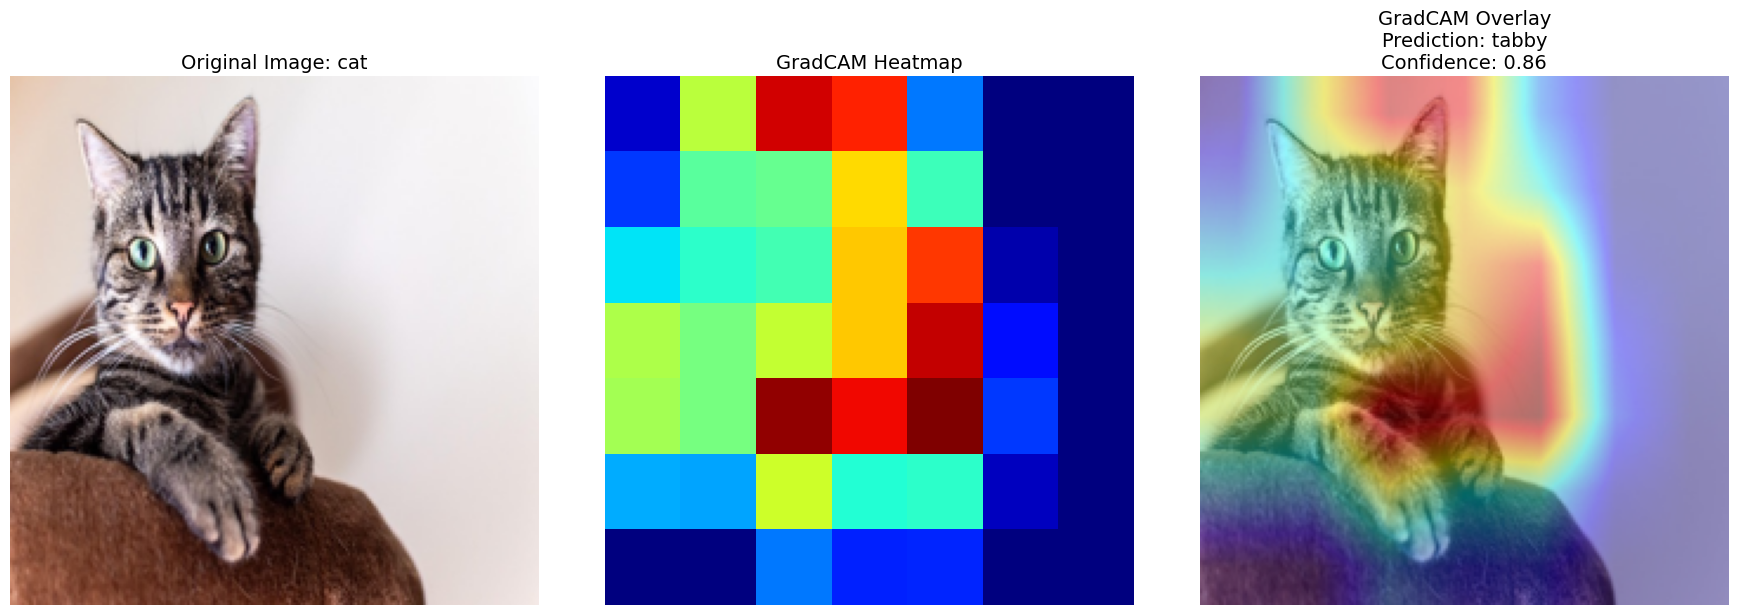

In [13]:
image_files = ['images/cat.jpg']
# Check that files exist
existing_files = [f for f in image_files if os.path.exists(f)]
for img_path in existing_files:
    # Use only base filename for saving overlays!
    title = os.path.splitext(os.path.basename(img_path))[0]
    print(f"Processing {title}...")
    img_display, heatmap, pred_class, pred_score = compute_gradcam(
        img_path, model, transform, device
    )
    if img_display is not None:
        visualize_gradcam(img_display, heatmap, pred_class, pred_score, title)
    else:
        print(f"Skipping visualization for {img_path}")

In [14]:
helper_utils.plot_widget(compute_gradcam, visualize_gradcam, model, transform, device, folder="images")

HTML(value='<h3>GradCAM Visualizer</h3>Select an image from <code>images</code>:')

interactive(children=(Dropdown(description='Select image:', layout=Layout(width='50%'), options=('bird.jpg', '…

Output()

## Conclusion

In this lab, you explored some of the most widely used techniques for interpreting deep convolutional neural networks, specifically **Saliency Maps** and **Class Activation Maps (Grad-CAM)**. By visualizing the "attention" of the model on your own images, you gained practical insights into how a state of the art classifier like ResNet50 reasons about visual information and makes predictions.

You successfully walked through the process of loading and preprocessing images to calculate saliency maps, identifying the specific pixels that most strongly influenced the decisions of the model. Furthermore, you utilized Grad-CAM to generate and overlay spatial heatmaps, clearly revealing which regions of the input drove the final prediction. By consolidating these steps into reusable and interactive tools, you are now equipped to apply these interpretability techniques to analyze and explain model behavior on any new set of images.